
================ FIRST 5 ROWS ================

   Age  Gender        BMI  Smoking  GeneticRisk  PhysicalActivity  \
0   58       1  16.085313        0            1          8.146251   
1   71       0  30.828784        0            1          9.361630   
2   48       1  38.785084        0            2          5.135179   
3   34       0  30.040296        0            0          9.502792   
4   62       1  35.479721        0            0          5.356890   

   AlcoholIntake  CancerHistory  Diagnosis  
0       4.148219              1          1  
1       3.519683              0          0  
2       4.728368              0          1  
3       2.044636              0          0  
4       3.309849              0          1  

================ DATASET SHAPE ================

(1500, 9)

================ COLUMN NAMES ================

Index(['Age', 'Gender', 'BMI', 'Smoking', 'GeneticRisk', 'PhysicalActivity',
       'AlcoholIntake', 'CancerHistory', 'Diagnosis'],
      dtype='object')

==

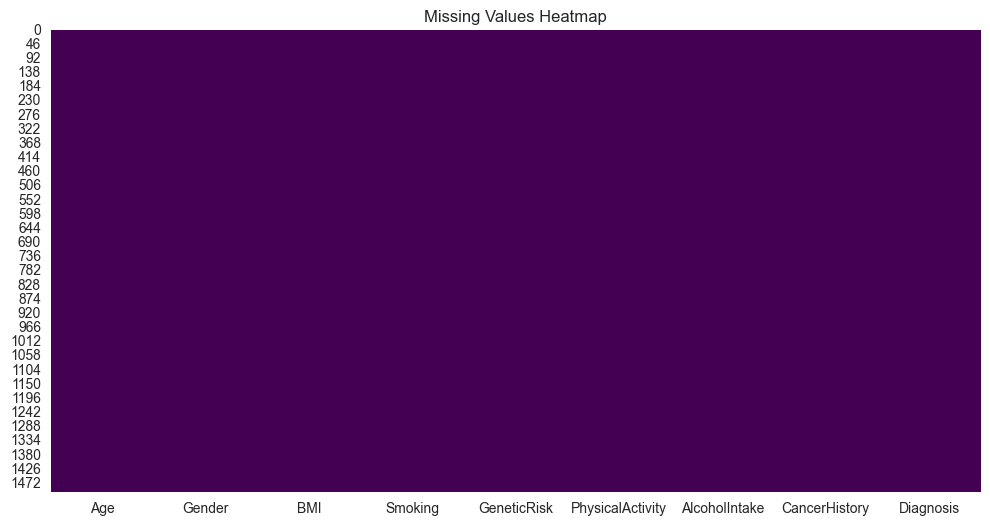


================ AFTER HANDLING MISSING VALUES ================

Age                 0
Gender              0
BMI                 0
Smoking             0
GeneticRisk         0
PhysicalActivity    0
AlcoholIntake       0
CancerHistory       0
Diagnosis           0
dtype: int64

================ DUPLICATE ROWS ================

Duplicate Rows: 0

================ DATASET SHAPE AFTER REMOVING DUPLICATES ================

(1500, 9)

================ STATISTICAL SUMMARY ================

               Age       Gender          BMI      Smoking  GeneticRisk  \
count  1500.000000  1500.000000  1500.000000  1500.000000  1500.000000   
mean     50.320000     0.490667    27.513321     0.269333     0.508667   
std      17.640968     0.500080     7.230012     0.443761     0.678895   
min      20.000000     0.000000    15.000291     0.000000     0.000000   
25%      35.000000     0.000000    21.483134     0.000000     0.000000   
50%      51.000000     0.000000    27.598494     0.000000     0.0000

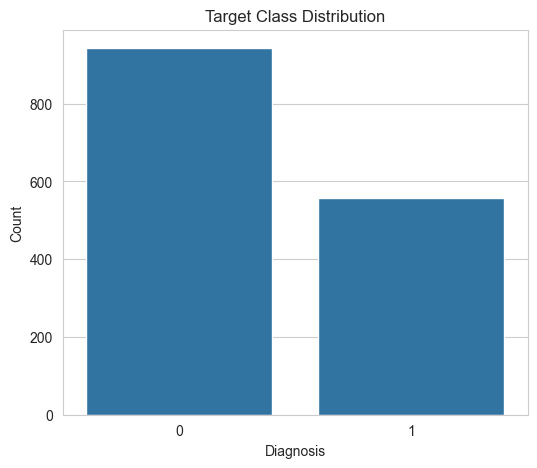

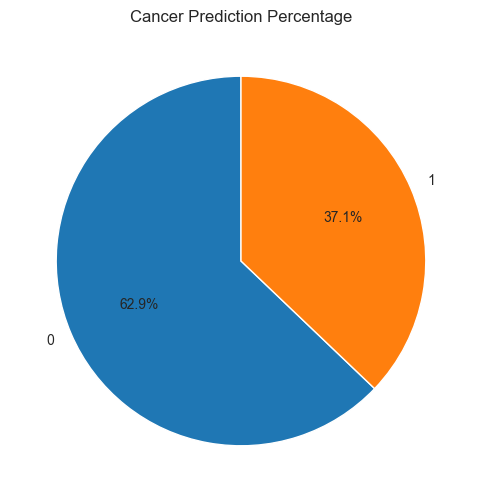

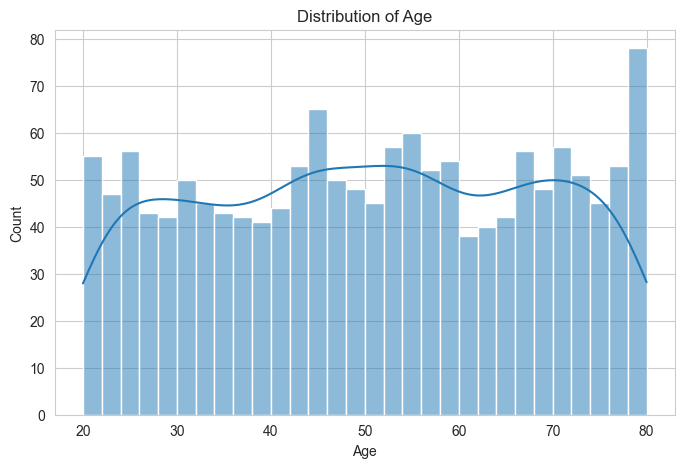

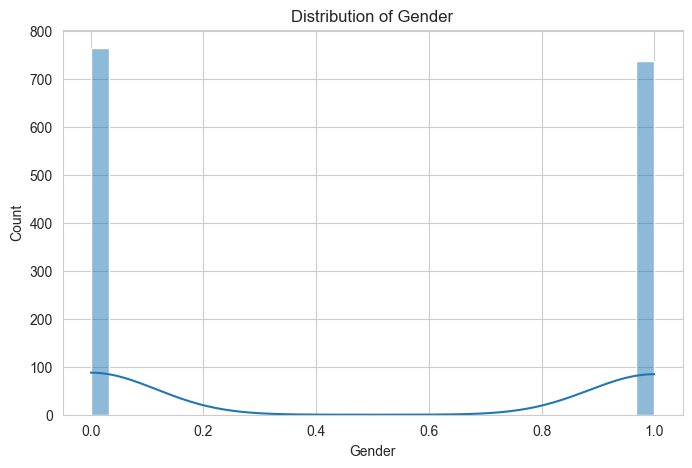

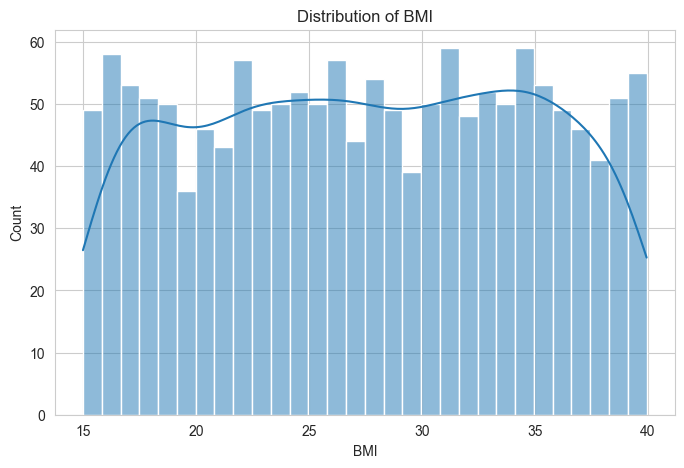

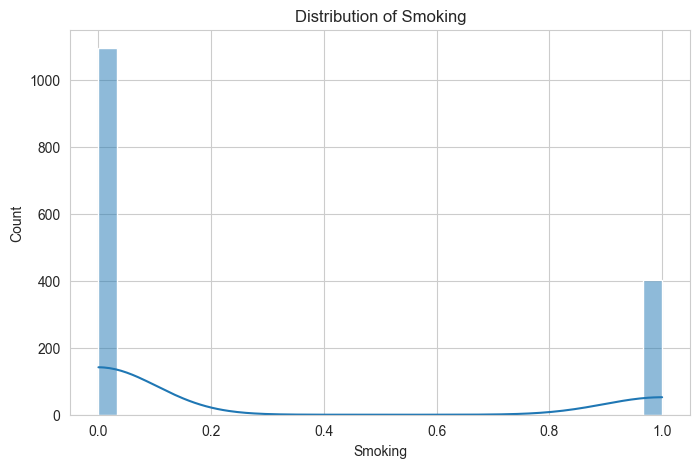

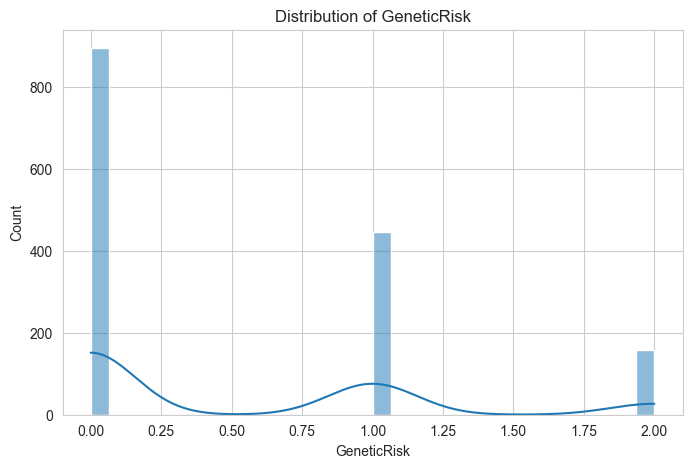

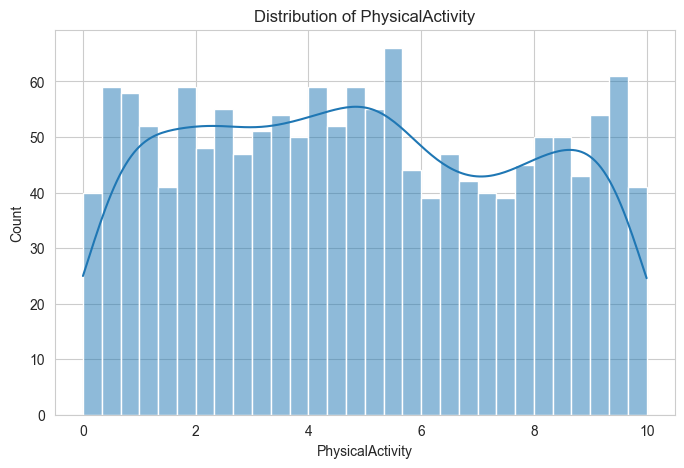

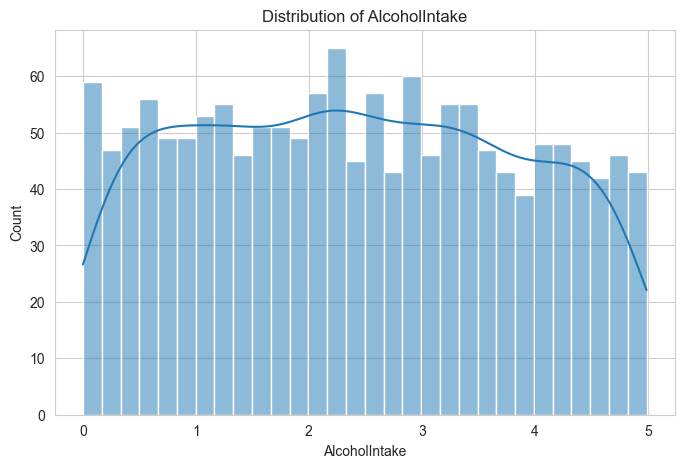

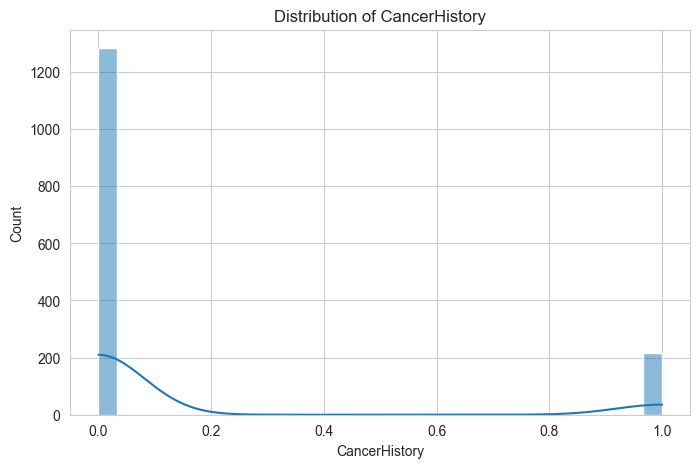

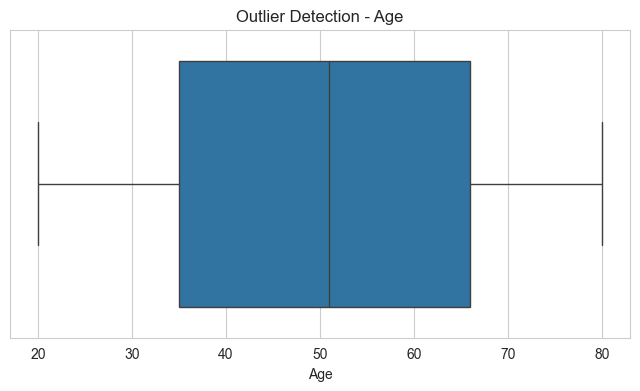

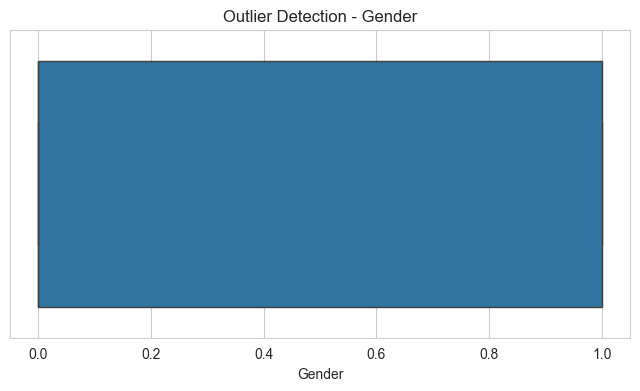

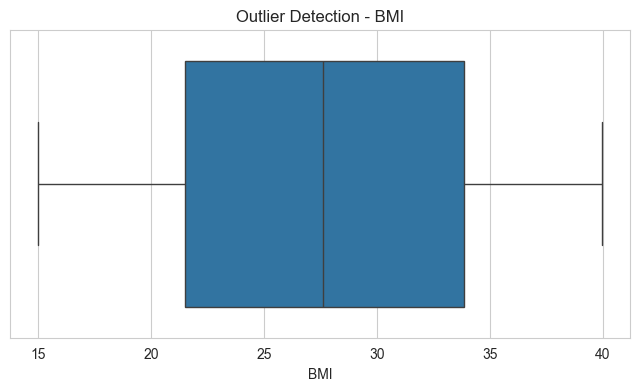

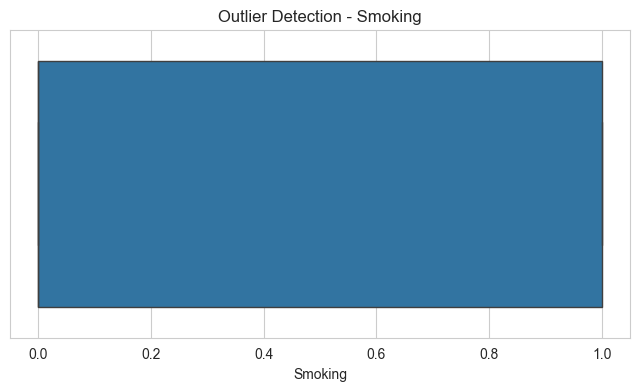

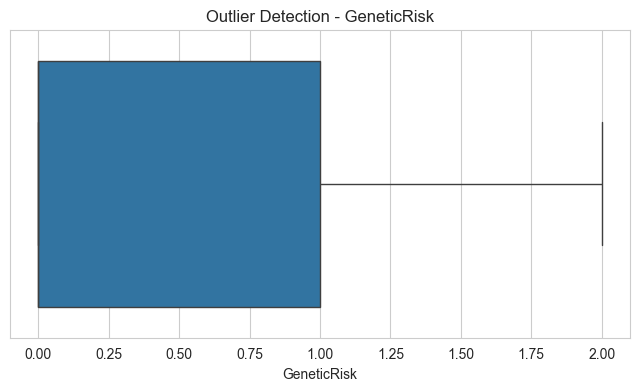

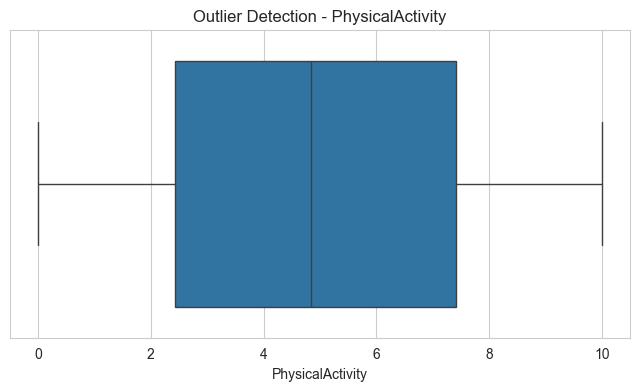

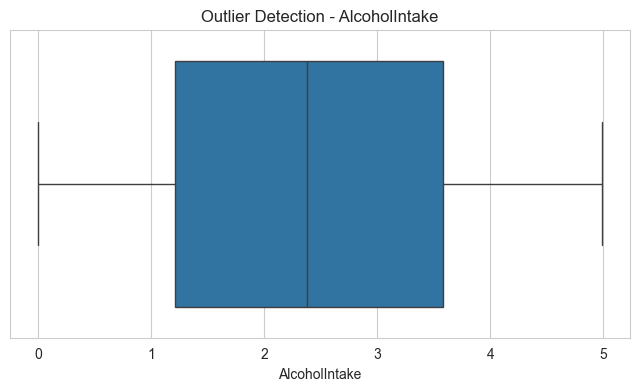

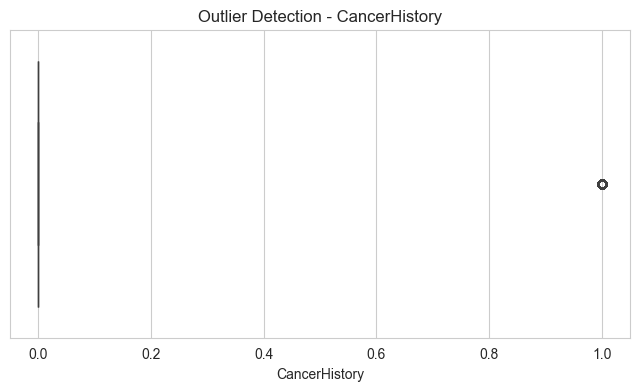


Outliers Handled Successfully

================ FINAL DATASET INFO ================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1500 non-null   float64
 1   Gender            1500 non-null   float64
 2   BMI               1500 non-null   float64
 3   Smoking           1500 non-null   float64
 4   GeneticRisk       1500 non-null   float64
 5   PhysicalActivity  1500 non-null   float64
 6   AlcoholIntake     1500 non-null   float64
 7   CancerHistory     1500 non-null   float64
 8   Diagnosis         1500 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 105.6 KB
None

================ FINAL MISSING VALUES ================

Age                 0
Gender              0
BMI                 0
Smoking             0
GeneticRisk         0
PhysicalActivity    0
AlcoholIntake       0
CancerHistory       0
D

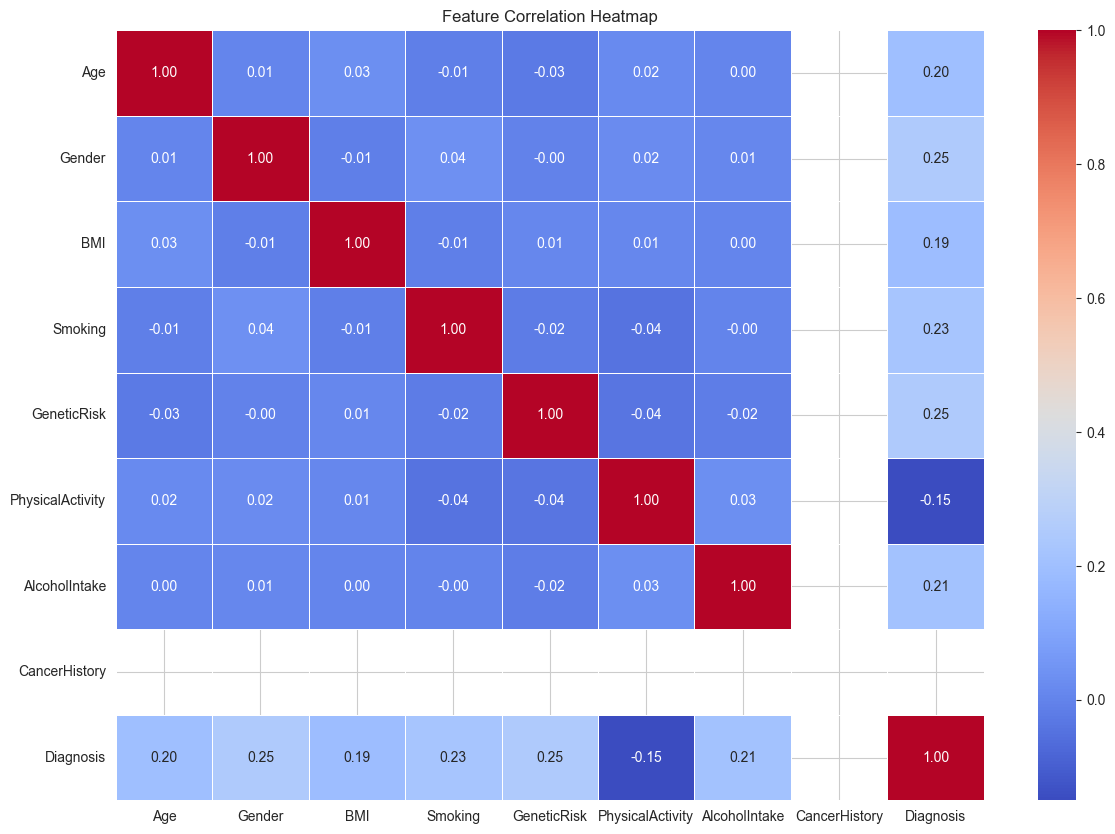

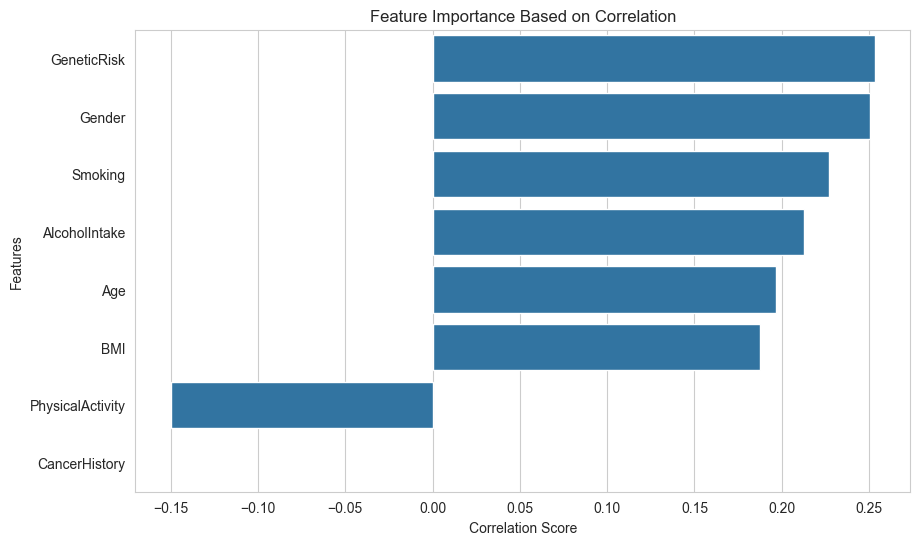

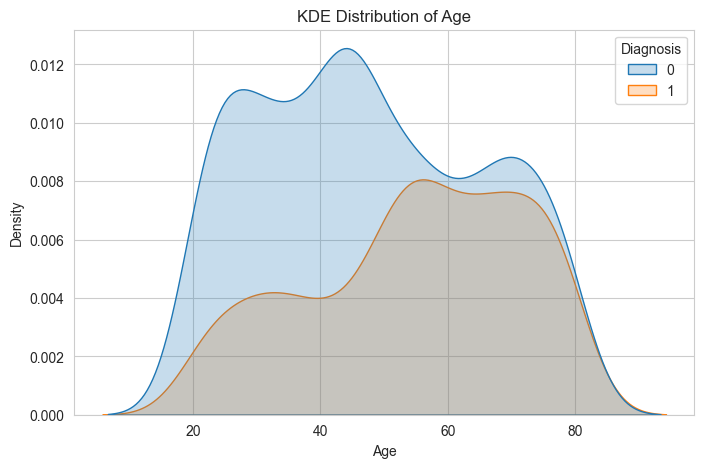

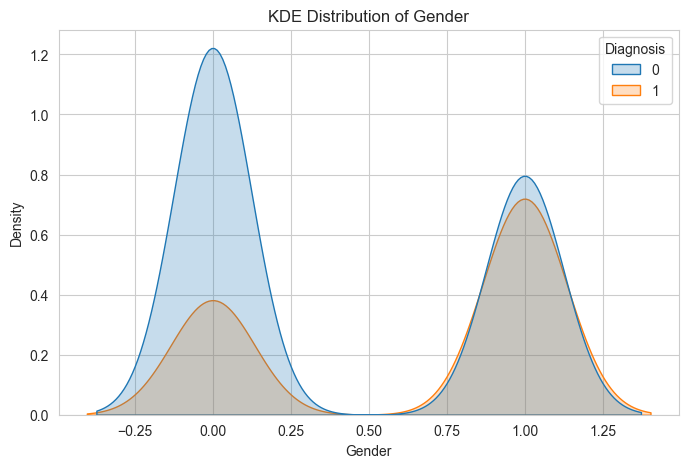

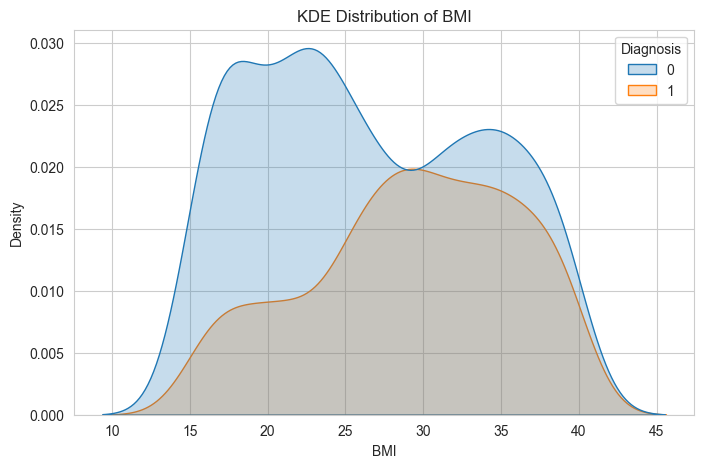

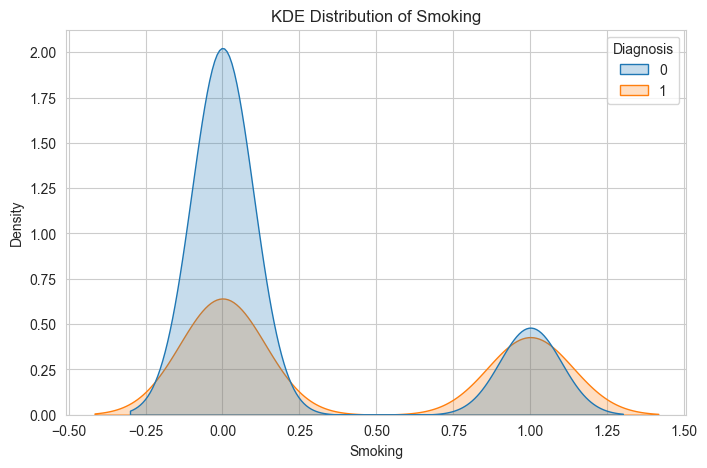

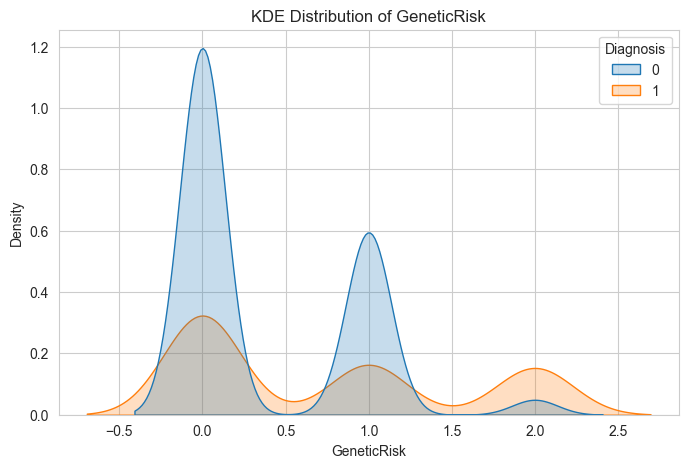

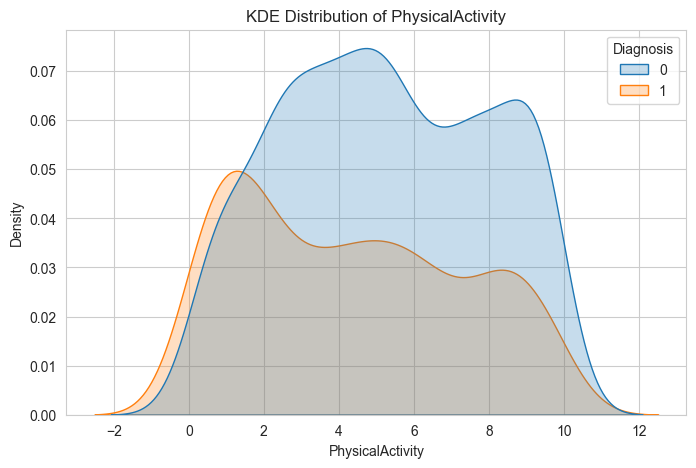

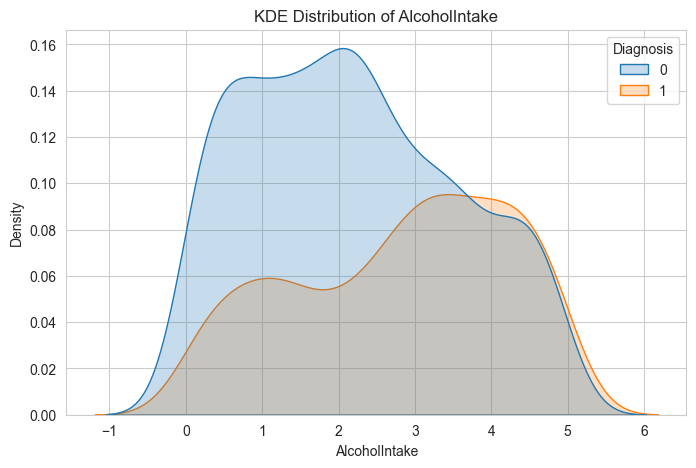

C:\Users\priya\AppData\Local\Temp\ipykernel_22956\1516794474.py:359: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


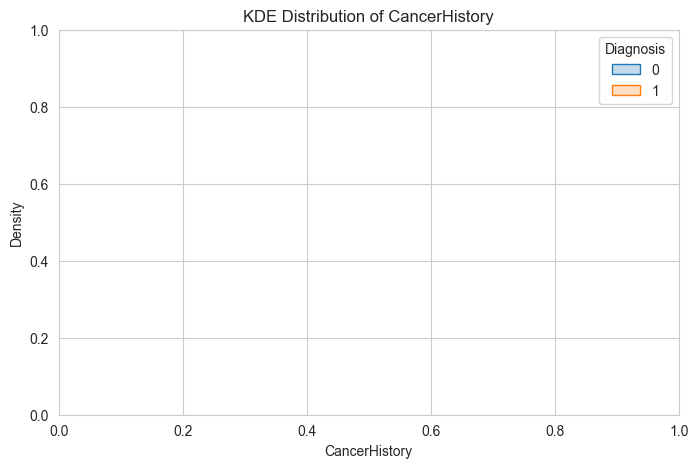

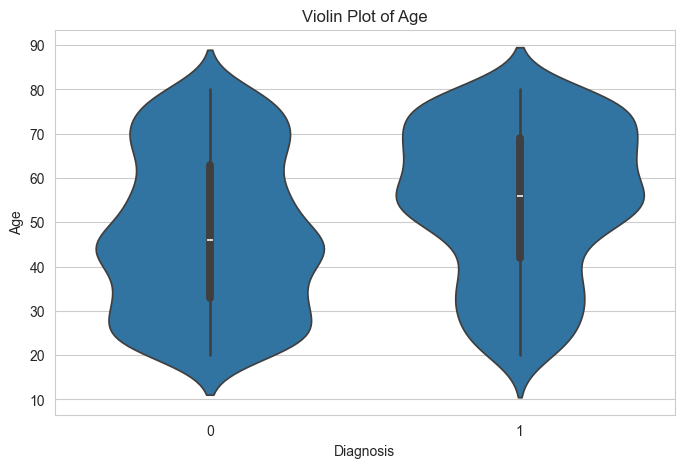

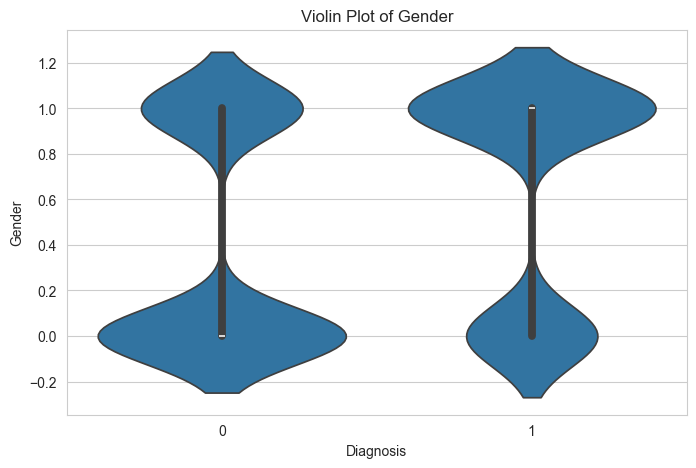

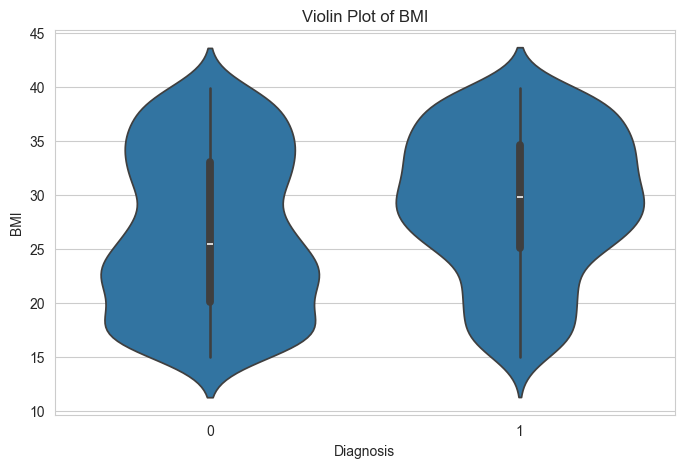

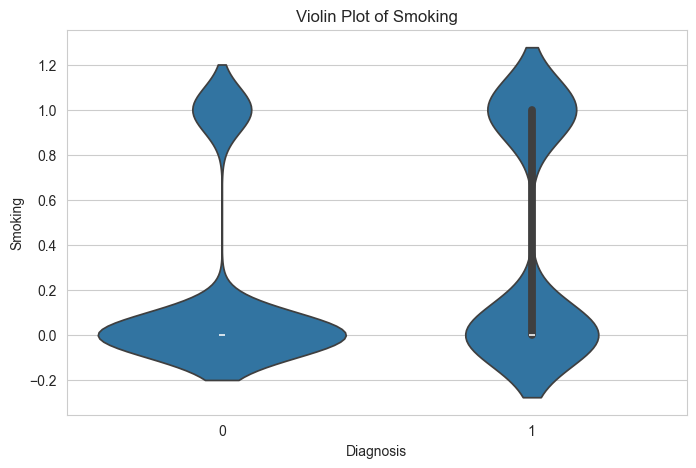

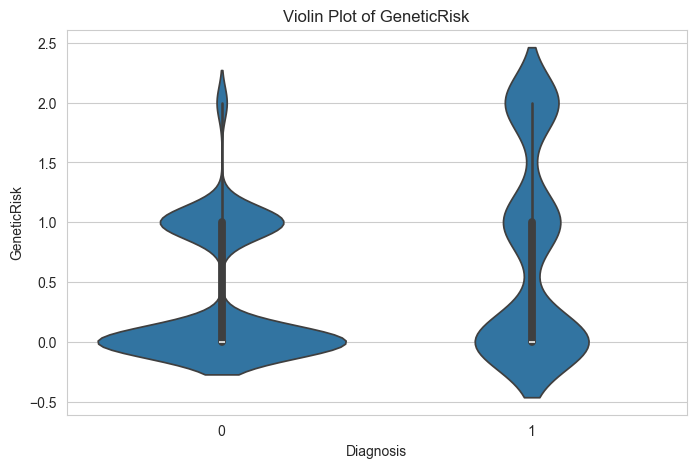

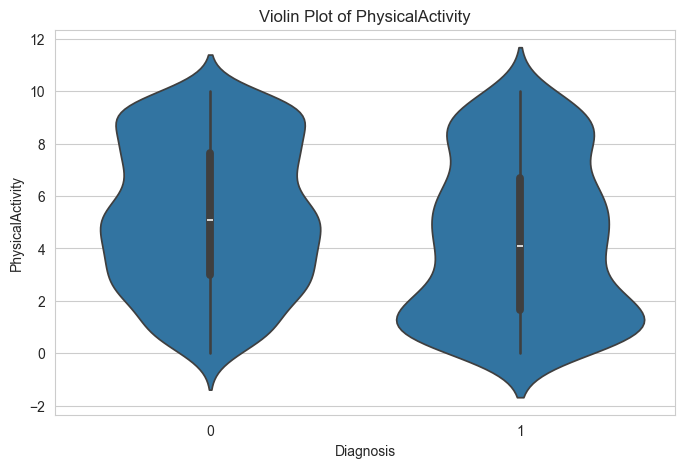

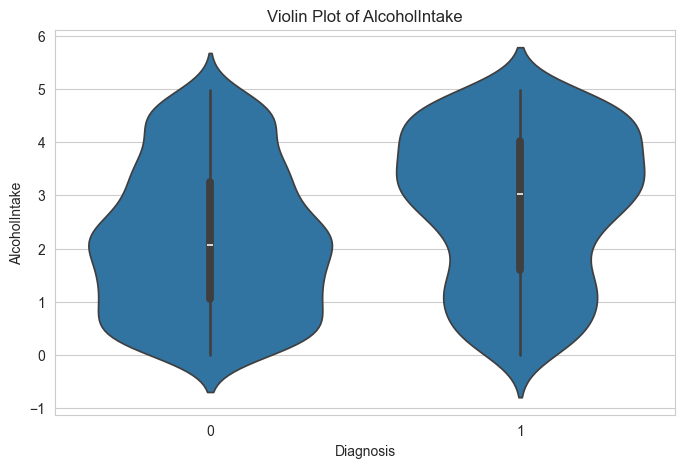

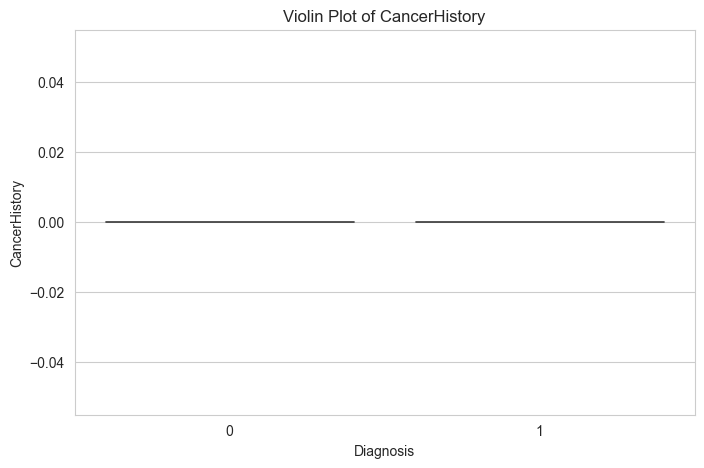

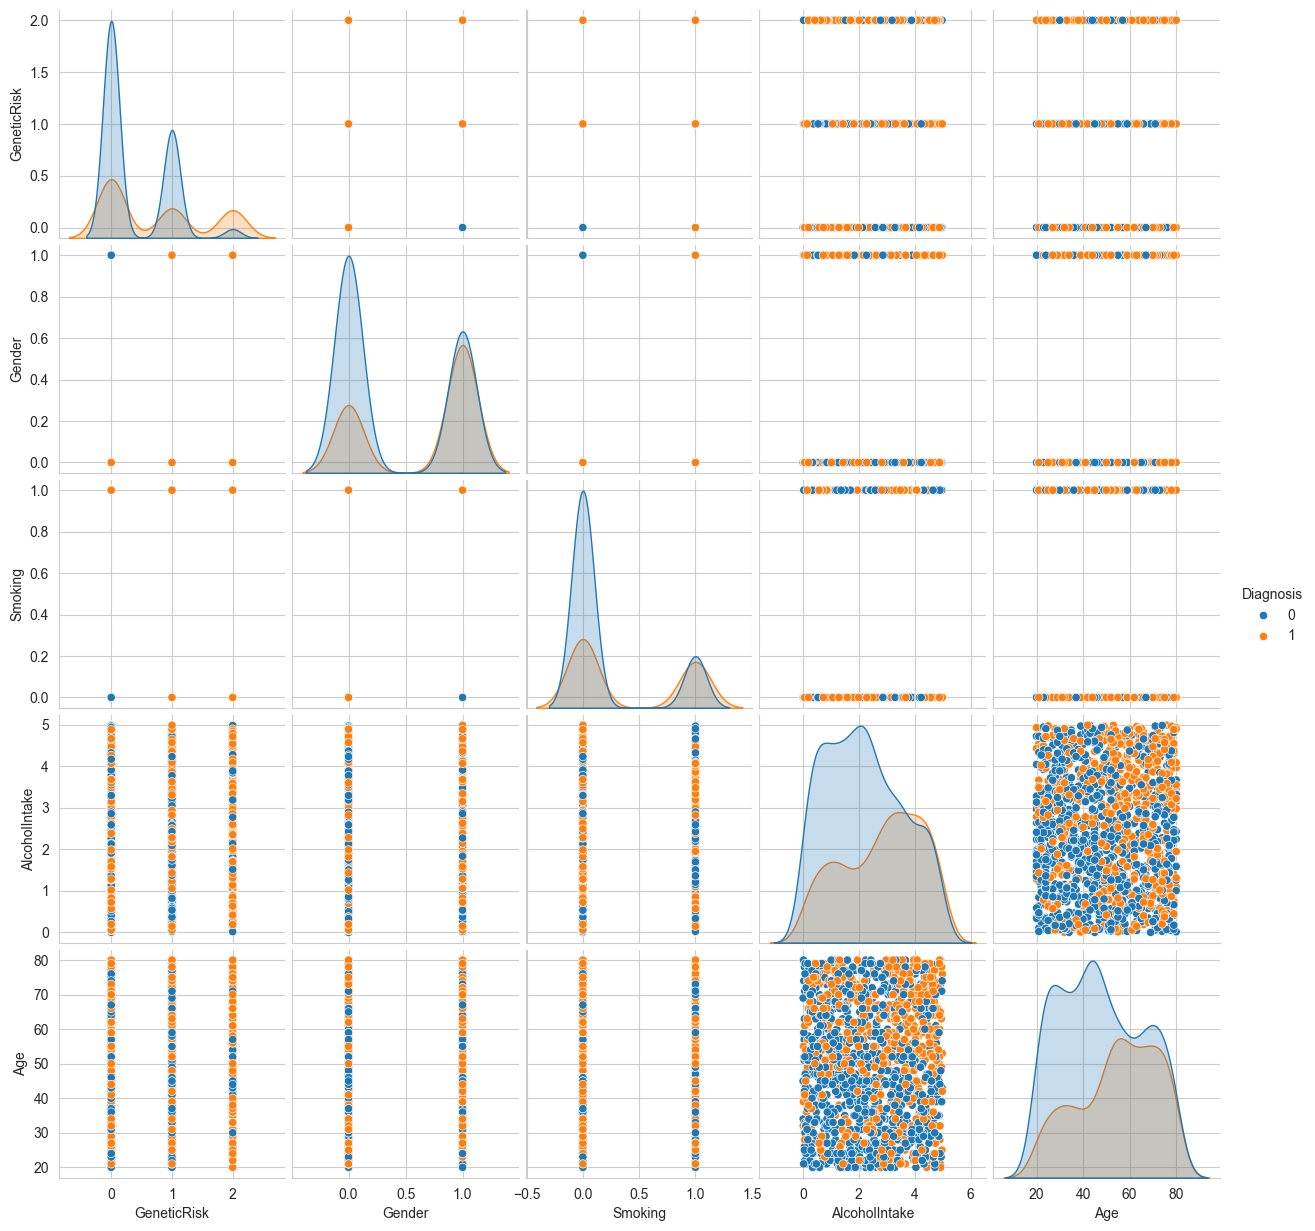


================ SKEWNESS CHECK ================

Age : -0.03
Gender : 0.04
BMI : -0.02
Smoking : 1.04
GeneticRisk : 0.98
PhysicalActivity : 0.08
AlcoholIntake : 0.06
CancerHistory : 0.00

CLEANED DATASET SAVED SUCCESSFULLY
File Name: cleaned_cancer_data.csv


In [1]:
# ==========================================================
# PROFESSIONAL DATA CLEANING WORKFLOW
# CANCER PREDICTION DATASET
# ==========================================================

# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Visualization Style
sns.set_style("whitegrid")

# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv(r"C:\Users\priya\Downloads\xip\cancer prediction\dataset\cancer_data.csv.csv")

# ==========================================================
# DISPLAY FIRST 5 ROWS
# ==========================================================

print("\n================ FIRST 5 ROWS ================\n")

print(df.head())

# ==========================================================
# DATASET SHAPE
# ==========================================================

print("\n================ DATASET SHAPE ================\n")

print(df.shape)

# ==========================================================
# COLUMN NAMES
# ==========================================================

print("\n================ COLUMN NAMES ================\n")

print(df.columns)

# ==========================================================
# DATASET INFO
# ==========================================================

print("\n================ DATASET INFO ================\n")

print(df.info())

# ==========================================================
# DATA TYPES
# ==========================================================

print("\n================ DATA TYPES ================\n")

print(df.dtypes)

# ==========================================================
# CHECK MISSING VALUES
# ==========================================================

print("\n================ MISSING VALUES ================\n")

print(df.isnull().sum())

# ==========================================================
# VISUALIZE MISSING VALUES
# ==========================================================

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap")

plt.show()

# ==========================================================
# HANDLE MISSING VALUES
# ==========================================================

for col in df.columns:

    # Categorical Columns
    if df[col].dtype == 'object':

        df[col] = df[col].fillna(
            df[col].mode()[0]
        )

    # Numerical Columns
    else:

        df[col] = df[col].fillna(
            df[col].median()
        )

print("\n================ AFTER HANDLING MISSING VALUES ================\n")

print(df.isnull().sum())

# ==========================================================
# CHECK DUPLICATES
# ==========================================================

print("\n================ DUPLICATE ROWS ================\n")

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

# ==========================================================
# REMOVE DUPLICATES
# ==========================================================

df = df.drop_duplicates()

print("\n================ DATASET SHAPE AFTER REMOVING DUPLICATES ================\n")

print(df.shape)

# ==========================================================
# STATISTICAL SUMMARY
# ==========================================================

print("\n================ STATISTICAL SUMMARY ================\n")

print(df.describe())

# ==========================================================
# DETECT TARGET COLUMN
# ==========================================================

possible_targets = [
    'Diagnosis',
    'Cancer',
    'Outcome',
    'Target',
    'Class'
]

target_col = None

for col in possible_targets:

    if col in df.columns:

        target_col = col

        break

print(f"\nDetected Target Column: {target_col}")

# ==========================================================
# TARGET DISTRIBUTION
# ==========================================================

print("\n================ TARGET DISTRIBUTION ================\n")

print(df[target_col].value_counts())

# ==========================================================
# TARGET COUNT PLOT
# ==========================================================

plt.figure(figsize=(6,5))

sns.countplot(
    x=target_col,
    data=df
)

plt.title("Target Class Distribution")

plt.xlabel(target_col)

plt.ylabel("Count")

plt.show()

# ==========================================================
# PIE CHART OF TARGET
# ==========================================================

target_counts = df[target_col].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    target_counts,
    labels=target_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Cancer Prediction Percentage")

plt.show()

# ==========================================================
# NUMERICAL COLUMNS
# ==========================================================

numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

# Remove Target Column
if target_col in numeric_cols:

    numeric_cols.remove(target_col)

# ==========================================================
# DISTRIBUTION PLOTS
# ==========================================================

for col in numeric_cols:

    plt.figure(figsize=(8,5))

    sns.histplot(
        df[col],
        kde=True,
        bins=30
    )

    plt.title(f"Distribution of {col}")

    plt.xlabel(col)

    plt.show()

# ==========================================================
# BOXPLOTS FOR OUTLIER DETECTION
# ==========================================================

for col in numeric_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Outlier Detection - {col}")

    plt.show()

# ==========================================================
# HANDLE OUTLIERS USING IQR METHOD
# ==========================================================

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)

    upper = Q3 + (1.5 * IQR)

    # Cap Lower Outliers
    df[col] = np.where(
        df[col] < lower,
        lower,
        df[col]
    )

    # Cap Upper Outliers
    df[col] = np.where(
        df[col] > upper,
        upper,
        df[col]
    )

print("\nOutliers Handled Successfully")

# ==========================================================
# VERIFY CLEANED DATA
# ==========================================================

print("\n================ FINAL DATASET INFO ================\n")

print(df.info())

print("\n================ FINAL MISSING VALUES ================\n")

print(df.isnull().sum())

print("\n================ FINAL DUPLICATES ================\n")

print(df.duplicated().sum())

# ==========================================================
# CORRELATION HEATMAP
# ==========================================================

plt.figure(figsize=(14,10))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")

plt.show()

# ==========================================================
# FEATURE RELATIONSHIP WITH TARGET
# ==========================================================

target_corr = correlation[target_col] \
    .drop(target_col) \
    .sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=target_corr.values,
    y=target_corr.index
)

plt.title("Feature Importance Based on Correlation")

plt.xlabel("Correlation Score")

plt.ylabel("Features")

plt.show()

# ==========================================================
# KDE PLOTS
# ==========================================================

for col in numeric_cols:

    plt.figure(figsize=(8,5))

    sns.kdeplot(
        data=df,
        x=col,
        hue=target_col,
        fill=True
    )

    plt.title(f"KDE Distribution of {col}")

    plt.show()

# ==========================================================
# VIOLIN PLOTS
# ==========================================================

for col in numeric_cols:

    plt.figure(figsize=(8,5))

    sns.violinplot(
        x=target_col,
        y=col,
        data=df
    )

    plt.title(f"Violin Plot of {col}")

    plt.show()

# ==========================================================
# PAIRPLOT
# ==========================================================

top_features = target_corr.abs() \
    .sort_values(ascending=False) \
    .head(5) \
    .index.tolist()

pairplot_df = df[top_features + [target_col]]

sns.pairplot(
    pairplot_df,
    hue=target_col,
    diag_kind='kde'
)

plt.show()

# ==========================================================
# CHECK SKEWNESS
# ==========================================================

print("\n================ SKEWNESS CHECK ================\n")

for col in numeric_cols:

    skewness = df[col].skew()

    print(f"{col} : {skewness:.2f}")

# ==========================================================
# SAVE CLEANED DATASET
# ==========================================================

df.to_csv(
    "../dataset/cleaned_cancer_data.csv",
    index=False
)

print("\n========================================")
print("CLEANED DATASET SAVED SUCCESSFULLY")
print("File Name: cleaned_cancer_data.csv")
print("========================================")